# Makes major basins (Atlantic, Pacific, Indian), which is necessary for making biomes.

### (Testing for POP grid and for regular 1° grid)

In [1]:
%matplotlib inline
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy
import cartopy.crs as ccrs
xr.set_options(keep_attrs=True)
import regionmask #for generating 1° ocean mask

## Standard 1° grid (for generating biomes from obs)

In [2]:
# Define the 1-degree latitude and longitude points
lon = np.arange(-179.5, 180, 1)
lat = np.arange(-89.5, 90, 1)

# Create the land mask using Natural Earth data (default resolution is 1:110m)
# The mask will be boolean (True for land) on the specified grid
land_mask = regionmask.defined_regions.natural_earth_v5_1_2.land_110.mask(lon, lat)
land_mask = land_mask.where(land_mask==0, other=1)

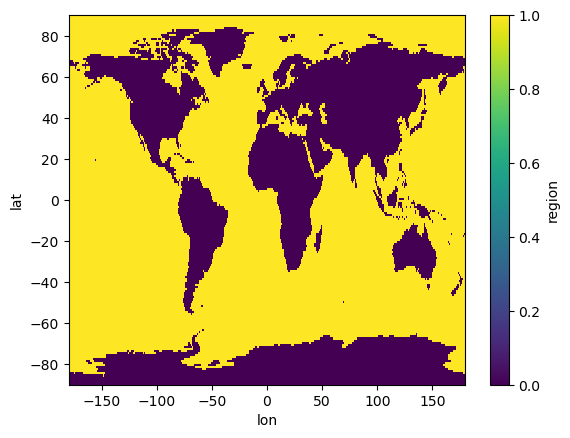

In [3]:
land_mask.plot()

### Define Atlantic, Indian, and Inland Seas, the rest will be the Pacific mask (reg num = 1)

In [4]:
Atl = np.array([[-100, 89], [30, 89], #top bounds
                [16,53],[1, 48], [-8, 23],[-6,9],[15,6],[23,-30],[23,-89], #east bounds
                [-93,-89],[-67.3,-74],[-71,-52],[-48,-9],[-79,8.8],[-81,8.5],[-85.4,14.3],[-101.8,20.8],
                [-102,32],[-100,52]]) #west bounds


Ind = np.array([[23,-89],[23,-30],[60,37],# west bounds
                [100.7,27],[104,-4],[111.6,-7.7],[130,-10],[145,-30],[145,-89]]) # east bounds

Inland_seas = np.array([[23,-30],[60,37],[58,53],[16,53],[1, 48], [-8, 23],[-6,9],[15,6]])

# Pac = np.array([[145,-89],[145,-30],[130,-10],[111.6,-7.7],[104,-4],[100.7,27],
#                [155,67],[-142,67],[-115,49],[-102,24],[-85.4,14.3],[-81,8.5],[-79,8.8],
#                [-48,-9],[-71,-52],[-67.3,-74],[-93,-89]])

regionmask.Regions([Ind, Atl,Inland_seas]) #, Pac])

<regionmask.Regions 'unnamed'>
overlap:  None

Regions:
0 r0 Region0
1 r1 Region1
2 r2 Region2

[3 regions]

In [5]:
names = ["Indian", "Atlantic", "Indian seas"] #, "Pacific"]
abbrevs = ["Ind", "Atl","Inland_seas"] #,"Pac"]

Basins = regionmask.Regions([Ind, Atl,Inland_seas], names=names, abbrevs=abbrevs, name="Major_basins")
Basins

<regionmask.Regions 'Major_basins'>
overlap:  None

Regions:
0         Ind      Indian
1         Atl    Atlantic
2 Inland_seas Indian seas

[3 regions]

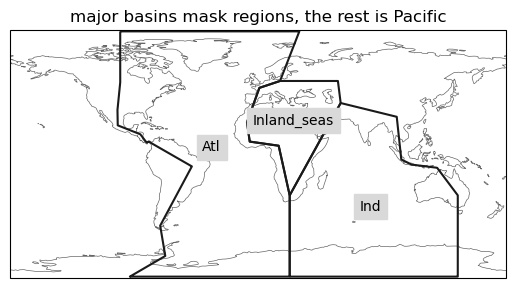

In [6]:

ax = Basins.plot(label="abbrev")
ax.set_title('major basins mask regions, the rest is Pacific')
# fine tune the extent
ax.set_extent([-180,180,-90,90], crs=ccrs.PlateCarree())

In [7]:
mask = Basins.mask(lon, lat)
mask = mask.where(land_mask==1)

# now add 2 to the numbers for the Indian (0) and Atltanic (1) regions 
# so they are regions 2 and 3, respectively

mask = (mask + 2).where(mask >= 0, other=1)

# then mask out land

mask = mask.where(land_mask == 1)

#mask = land_mask.where(mask == np.nan, other=mask)

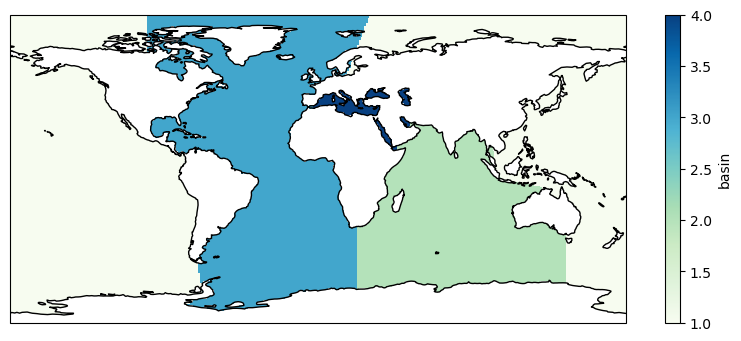

In [8]:
fig = plt.figure(figsize=(10,4))

ax = fig.add_subplot(1,1,1, projection=ccrs.PlateCarree())

h = mask.plot(
    transform=ccrs.PlateCarree(),
    cmap="GnBu",
    add_colorbar=False,
    vmax=4,
)

ax.coastlines()

# add the outlines of the regions
#Basins.plot_regions(ax=ax, add_label=False)
fig.colorbar(h, label='basin');

ax.set_extent([-180,180,-90,90], crs=ccrs.PlateCarree())

### write out the netcdf

In [9]:
ds_out = xr.Dataset()

ds_out.attrs['notes'] =  'Major basins mask for INDEX-BGC project on the 1 degree grid'
ds_out.attrs['notes2'] = 'created by Kristen Krumhardt, March 30, 2026'

ds_out['basin'] = mask

ds_out.to_netcdf('major_basins_1x1.nc', mode='w')

## Major basins on the POP grid

In [10]:
import pop_tools

### First, get the pop grid information, so we have lon, lat
ds_grid = pop_tools.get_grid('POP_gx1v7')
lats = ds_grid.TLAT
lons = ds_grid.TLONG

/glade/u/apps/opt/miniforge/envs/npl-2026a/lib/python3.13/site-packages/pop_tools/__init__.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution


In [11]:
mask = Basins.mask(lons, lats)
#mask = Basins.mask(lon, lat)
#mask = mask.where(land_mask==1)

# now add 2 to the numbers for the Indian (0) and Atltanic (1) regions 
# so they are regions 2 and 3, respectively

mask = (mask + 2).where(mask >= 0, other=1)

# then mask out land

mask = mask.where(ds_grid.REGION_MASK > 0)

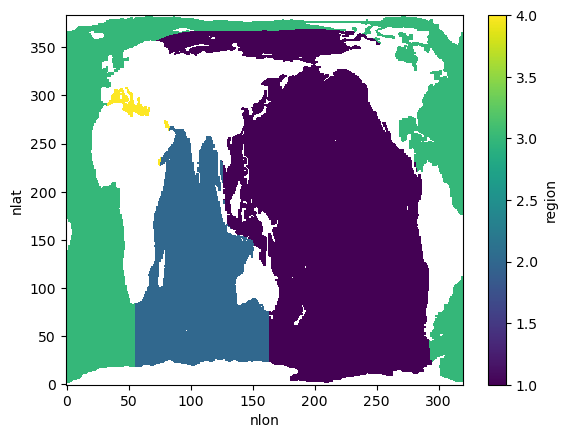

In [12]:
mask.where(ds_grid.REGION_MASK>0).plot()

### write out POP grid dataset

In [13]:
ds_out = xr.Dataset()

ds_out.attrs['notes'] =  'Major basins mask for INDEX-BGC project on the x1 POP grid'
ds_out.attrs['notes2'] = 'created by Kristen Krumhardt, March 30, 2026'

ds_out['basin'] = mask

ds_out.to_netcdf('major_basins_POP.nc', mode='w')

#### Will add additional grids as project develops ...